# Sales Prediction

### **Load the forecasting dataset**

In [144]:

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

forecast_df = pd.read_csv(
    "../data/processed/forecast_dataset.csv",
    parse_dates=["Date"]
)

forecast_df.head()

,Date,Year,Month,DayOfWeek,DayOfMonth,IsWeekend,MonthSin,MonthCos,DayOfWeekSin,DayOfWeekCos,Lag_1,Lag_7,Lag_14,Lag_28,RollingMean_7,RollingMean_14,RollingMean_28,RollingStd_7,Revenue
0,2009-12-29,2009,12,1,29,0,-2.449294e-16,1.000000,0.781831,0.623490,0.0,28017.28,50262.29,54351.23,5552.375714,17320.607143,29374.426786,10699.487850,0.0
1,2009-12-30,2009,12,2,30,0,-2.449294e-16,1.000000,0.974928,-0.222521,0.0,10849.35,52545.55,63172.58,1549.907143,13730.443571,27433.311429,4100.668855,0.0
2,2009-12-31,2009,12,3,31,0,-2.449294e-16,1.000000,0.433884,-0.900969,0.0,0.00,30638.25,73972.45,0.000000,9977.190000,25177.147857,0.000000,0.0
3,2010-01-01,2010,1,4,1,0,5.000000e-01,0.866025,-0.433884,-0.900969,0.0,0.00,42470.29,40582.32,0.000000,7788.743571,22535.274643,0.000000,0.0
4,2010-01-02,2010,1,5,2,1,5.000000e-01,0.866025,-0.974928,-0.222521,0.0,0.00,0.00,9803.05,0.000000,4755.151429,21085.906071,0.000000,0.0


### **Visualize Daily Revenue**

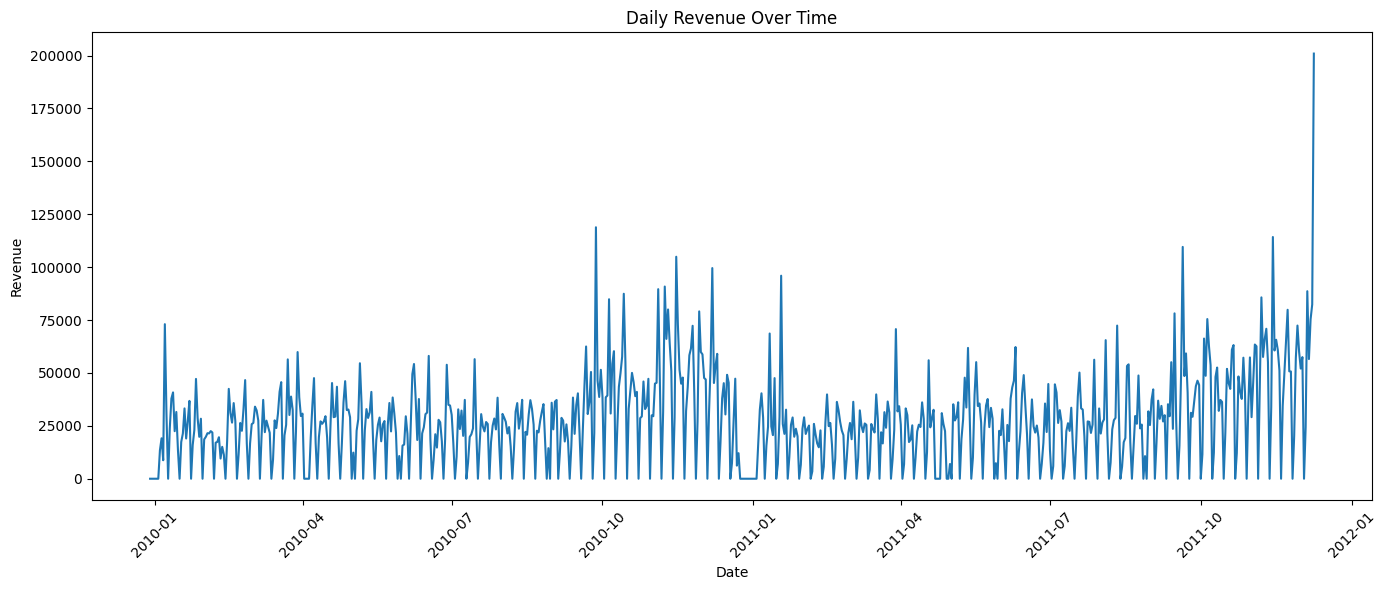

In [145]:
plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Revenue"]
)

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Monthly Revenue**

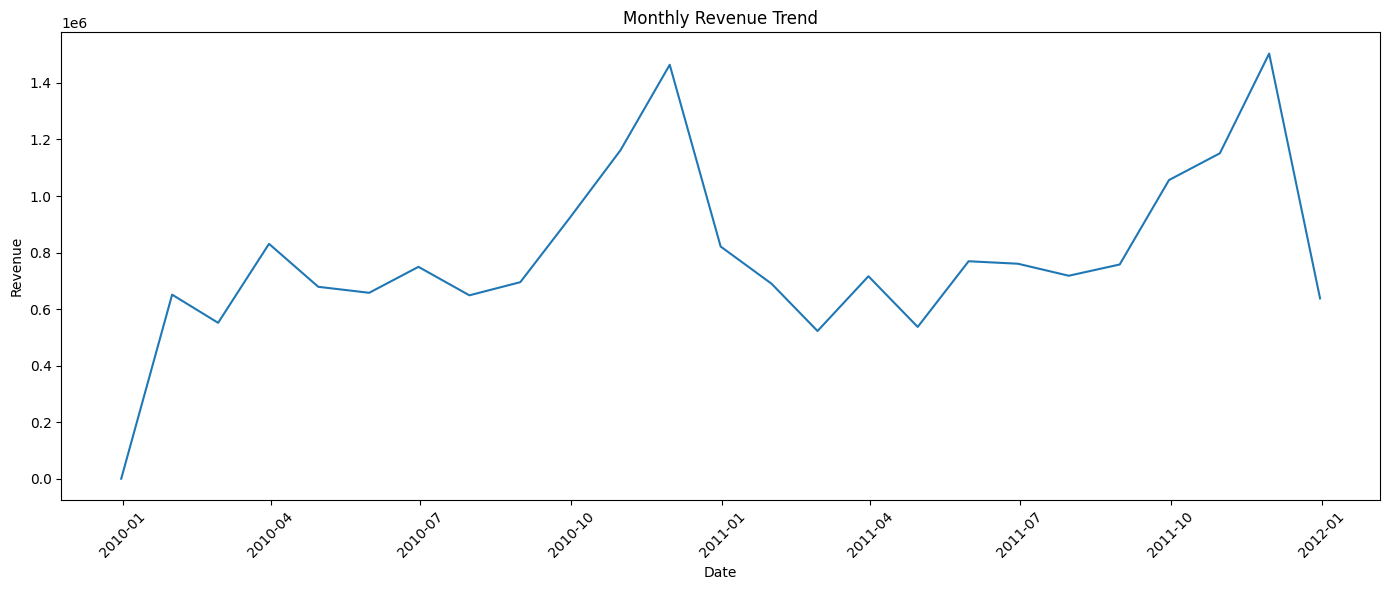

In [146]:
monthly_revenue = (
    forecast_df
    .set_index("Date")["Revenue"]
    .resample("ME")
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### **Average Revenue by Day of Week**

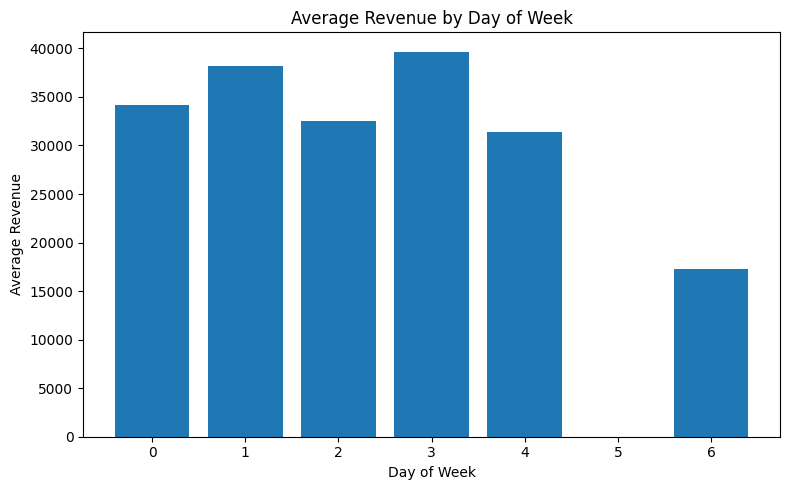

In [147]:
day_revenue = (
    forecast_df
    .groupby("DayOfWeek")["Revenue"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    day_revenue.index,
    day_revenue.values
)

plt.title("Average Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Revenue")

plt.tight_layout()
plt.show()

### **Prepare X and Y**

In [148]:
features = [
    "Year",
    "Month",
    "DayOfWeek",
    "DayOfMonth",
    "IsWeekend",
    "MonthSin",
    "MonthCos",
    "DayOfWeekSin",
    "DayOfWeekCos",
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_28",
    "RollingMean_7",
    "RollingMean_14",
    "RollingMean_28",
    "RollingStd_7"
]

X = forecast_df[features]
y = forecast_df["Revenue"]

**Check:**

In [149]:
print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['Year', 'Month', 'DayOfWeek', 'DayOfMonth', 'IsWeekend', 'MonthSin', 'MonthCos', 'DayOfWeekSin', 'DayOfWeekCos', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_28', 'RollingMean_7', 'RollingMean_14', 'RollingMean_28', 'RollingStd_7']

X shape: (711, 17)
y shape: (711,)


### **Split the data set**

In [150]:
n = len(forecast_df)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_df = forecast_df.iloc[:train_end]
validation_df = forecast_df.iloc[train_end:validation_end]
test_df = forecast_df.iloc[validation_end:]

In [151]:
X_train = train_df[features]
y_train = train_df["Revenue"]

X_validation = validation_df[features]
y_validation = validation_df["Revenue"]

X_test = test_df[features]
y_test = test_df["Revenue"]

**Check:**

In [152]:
print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

print("\nTraining dates:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nValidation dates:")
print(validation_df["Date"].min(), "to", validation_df["Date"].max())

print("\nTest dates:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

Training: (497, 17)
Validation: (107, 17)
Test: (107, 17)

Training dates:
2009-12-29 00:00:00 to 2011-05-09 00:00:00

Validation dates:
2011-05-10 00:00:00 to 2011-08-24 00:00:00

Test dates:
2011-08-25 00:00:00 to 2011-12-09 00:00:00


### **Train the model**

In [153]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    validation_pred = model.predict(X_validation)

    mae = mean_absolute_error(
        y_validation,
        validation_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            validation_pred
        )
    )

    r2 = r2_score(
        y_validation,
        validation_pred
    )

    results[name] = {
        "model": model,
        "prediction": validation_pred,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

    print(f"{name:20s}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")
    print()

Linear Regression   
MAE : 9124.07
RMSE: 11554.16
R²  : 0.5230

Random Forest       
MAE : 8408.76
RMSE: 11901.30
R²  : 0.4940



### **Model Comparison**

In [154]:
comparison = pd.DataFrame({
    "Model": results.keys(),
    "MAE": [results[name]["MAE"] for name in results],
    "RMSE": [results[name]["RMSE"] for name in results],
    "R²": [results[name]["R²"] for name in results]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,9124.068794,11554.162371,0.523047
1,Random Forest,8408.761338,11901.297765,0.493957


In [155]:
best_name = max(
    results,
    key=lambda name: results[name]["R²"]
)

best_model = results[best_name]["model"]

print("Best model:", best_name)
print("Validation R²:", results[best_name]["R²"])

Best model: Linear Regression
Validation R²: 0.5230469921220162


### **evaluate**

In [156]:
test_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("Final Model:", best_name)
print("Test MAE :", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²  :", test_r2)

Final Model: Linear Regression
Test MAE : 13366.796946817256
Test RMSE: 21373.880395069766
Test R²  : 0.4771091967391776


### **Actual vs Predicted Revenue**

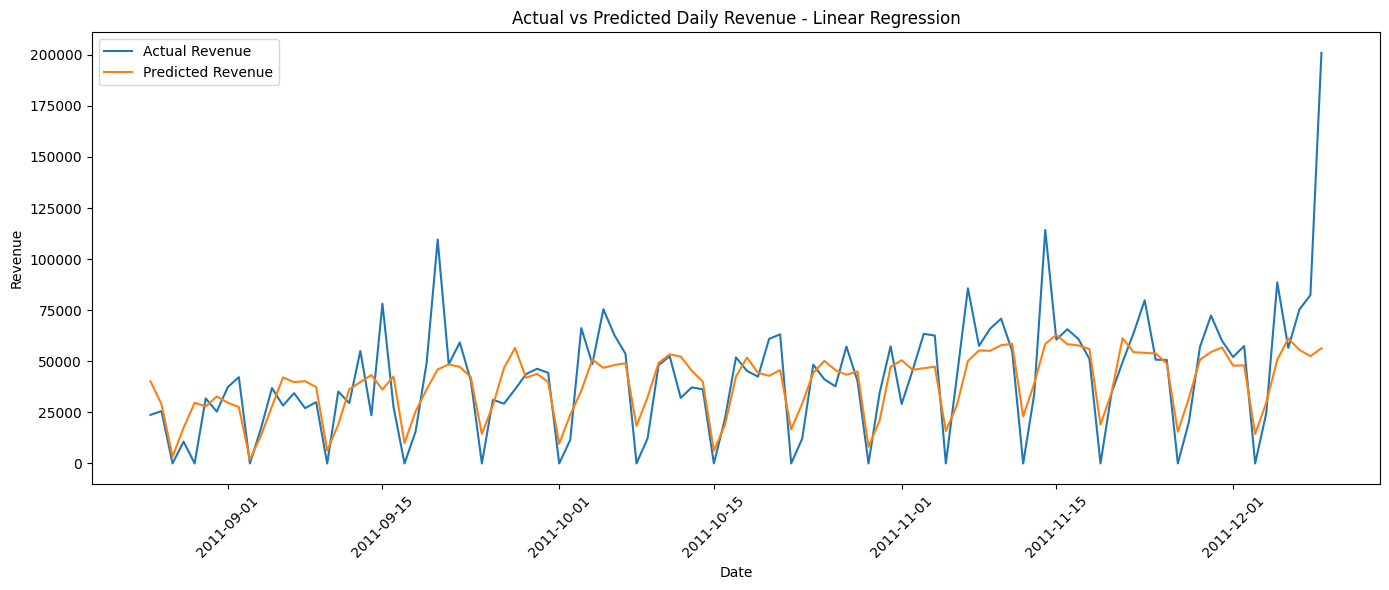

In [157]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df["Date"],
    y_test.values,
    label="Actual Revenue"
)

plt.plot(
    test_df["Date"],
    test_pred,
    label="Predicted Revenue"
)

plt.title(f"Actual vs Predicted Daily Revenue - {best_name}")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### **Prediction Results**

In [158]:
prediction_results = pd.DataFrame({
    "Date": test_df["Date"].values,
    "Actual Revenue": y_test.values,
    "Predicted Revenue": test_pred
})

prediction_results["Error"] = (
    prediction_results["Actual Revenue"]
    - prediction_results["Predicted Revenue"]
)

prediction_results.head(10)

,Date,Actual Revenue,Predicted Revenue,Error
0,2011-08-25,23773.43,40235.642099,-16462.212099
1,2011-08-26,25610.29,28992.825907,-3382.535907
2,2011-08-27,0.00,3322.016953,-3322.016953
3,2011-08-28,10686.56,17483.253629,-6796.693629
4,2011-08-29,0.00,29705.656946,-29705.656946
5,2011-08-30,31837.77,27896.663645,3941.106355
6,2011-08-31,25367.22,32783.064074,-7415.844074
7,2011-09-01,37358.62,29726.606975,7632.013025
8,2011-09-02,42226.28,27641.830279,14584.449721
9,2011-09-03,0.00,1890.327476,-1890.327476


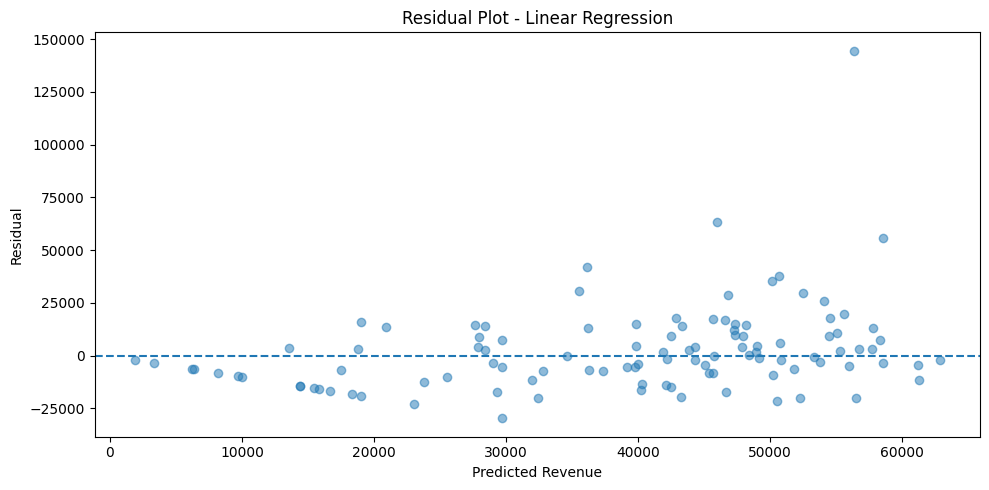

In [159]:

residuals = y_test.values - test_pred

plt.figure(figsize=(10, 5))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(f"Residual Plot - {best_name}")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

In [160]:
print("Mean Residual:", residuals.mean())
print("Maximum Error:", np.max(np.abs(residuals)))
print("Minimum Error:", np.min(np.abs(residuals)))

Mean Residual: 2779.90924145276
Maximum Error: 144545.98754269214
Minimum Error: 96.32079457720829


The residual plot shows the difference between actual and predicted revenue. Residuals distributed around zero indicate that the model does not consistently overestimate or underestimate revenue.

### **Predicting Daily Revenue**

In [161]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]

print("Predicted Revenue:", round(prediction, 2))
print("Actual Revenue:", round(y_test.iloc[0], 2))

Predicted Revenue: 40235.64
Actual Revenue: 23773.43


### **Feature Importance**


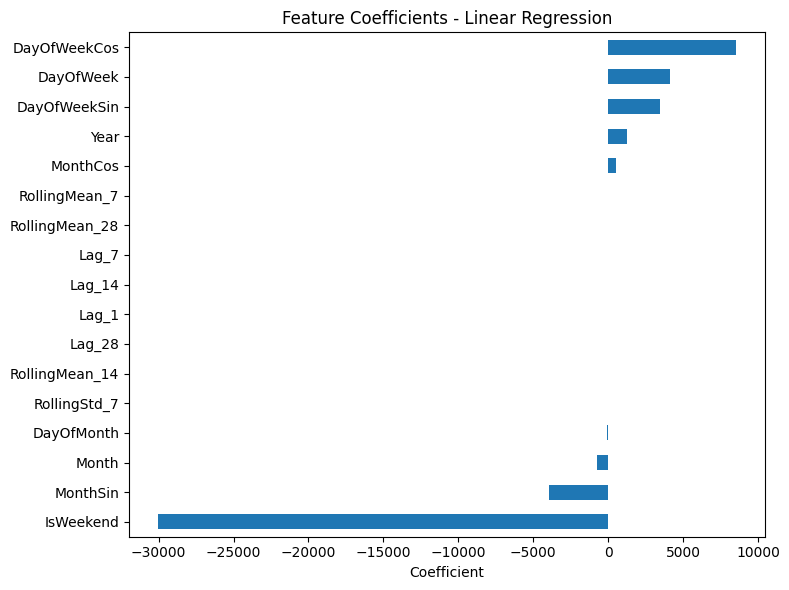

IsWeekend        -30052.113165
DayOfWeekCos       8527.405154
DayOfWeek          4164.221646
MonthSin          -3923.172831
DayOfWeekSin       3458.337991
Year               1262.536490
Month              -720.566992
MonthCos            552.352096
DayOfMonth          -50.538688
RollingMean_7         1.030383
RollingStd_7         -0.400748
RollingMean_14       -0.324497
RollingMean_28        0.103273
Lag_7                 0.091705
Lag_14                0.075489
Lag_1                 0.068339
Lag_28                0.065126
dtype: float64


In [162]:

if best_name == "Random Forest":

    importances = pd.Series(
        best_model.feature_importances_,
        index=features
    ).sort_values()

    importances.plot(
        kind="barh",
        figsize=(8, 6)
    )

    plt.xlabel("Importance")
    plt.title(f"Feature Importance - {best_name}")

    plt.tight_layout()
    plt.show()

    print(importances.sort_values(ascending=False))


elif best_name == "Linear Regression":

    coefficients = pd.Series(
        best_model.coef_,
        index=features
    ).sort_values()

    coefficients.plot(
        kind="barh",
        figsize=(8, 6)
    )

    plt.xlabel("Coefficient")
    plt.title(f"Feature Coefficients - {best_name}")

    plt.tight_layout()
    plt.show()

    print(
        coefficients.sort_values(
            key=abs,
            ascending=False
        )
    )

In [163]:
joblib.dump(
    best_model,
    "../data/models/sales_prediction_model.pkl"
)


['../data/models/sales_prediction_model.pkl']

In [165]:
joblib.dump(
    features,
    "../data/models/sales_prediction_features.pkl"
)

['../data/models/sales_prediction_features.pkl']

### **Final conclusion**

**The sales prediction model was developed using historical daily revenue, calendar-based features, lag features, and rolling statistics. Linear Regression and Random Forest Regression were trained and compared using MAE, RMSE, and R². The model with the best validation performance was selected and evaluated on unseen test data. The final model can be used to estimate future daily sales revenue based on historical sales patterns.**